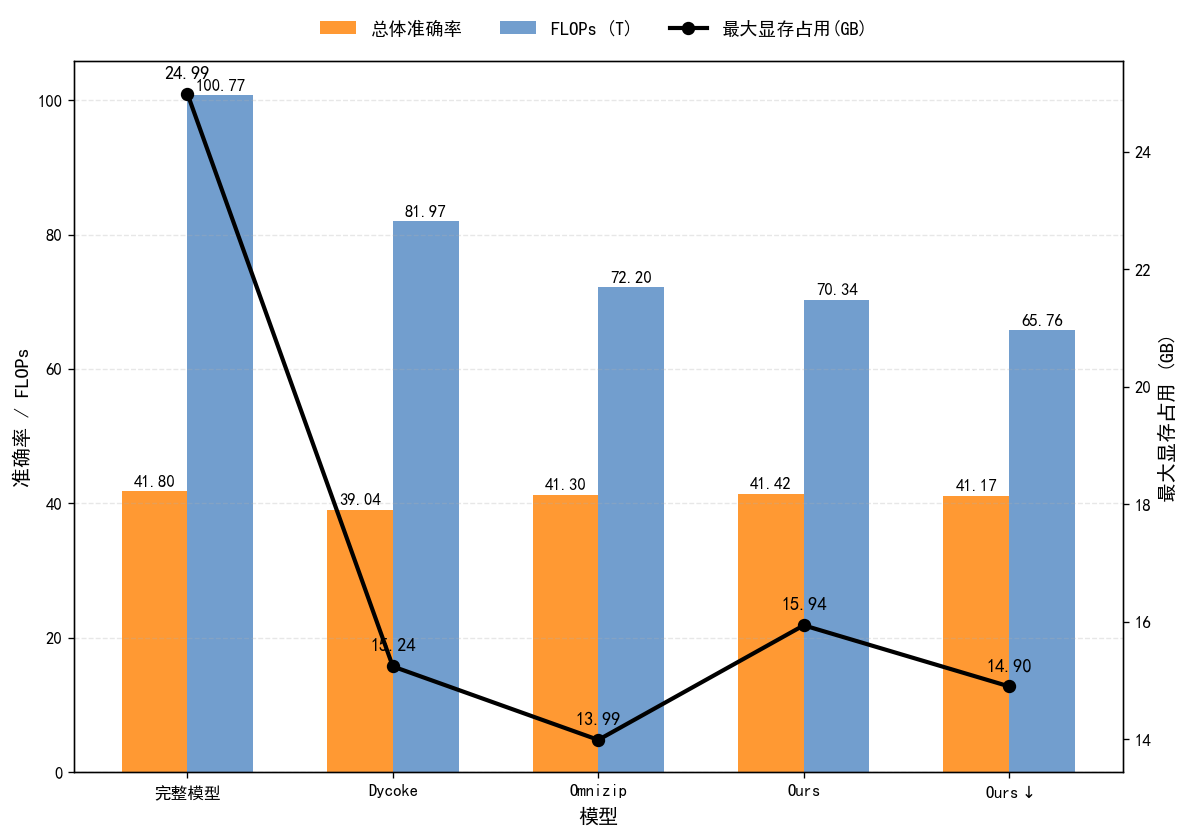

In [1]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "Noto Sans CJK SC"]
plt.rcParams["axes.unicode_minus"] = False

# 数据
models = ['完整模型', 'Dycoke', 'Omnizip', 'Ours', 'Ours$\\downarrow$']
accuracy    = [41.80, 39.04, 41.30, 41.42, 41.17]   # 橙色柱：总体正确率
flops       = [100.77, 81.97, 72.20, 70.34, 65.76]  # 柱子：FLOPs
max_memory  = [24.99, 15.24, 13.99, 15.94, 14.90]   # 折线：最大显存占用

# 绘图
fig, ax1 = plt.subplots(figsize=(10, 6.8), dpi=120)
ax2 = ax1.twinx()

x = np.arange(len(models))
width = 0.32

# 柱状图
bar1 = ax1.bar(x - width/2, accuracy, width, label='总体准确率', color='#ff9933')
bar2 = ax1.bar(x + width/2, flops, width, label='FLOPs (T)', color='#729ece')

# 显存折线（圆点）
ax2.plot(x, max_memory, 'o-', color='#000000', linewidth=2.5, markersize=7, label='最大显存占用(GB)')

# 轴标签
ax1.set_xlabel('模型', fontsize=12)
ax1.set_ylabel('准确率 / FLOPs', fontsize=12)
ax2.set_ylabel('最大显存占用 (GB)', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(models)

# 网格
ax1.grid(axis='y', linestyle='--', alpha=0.3)

# -------------------------- 数值标注（全部清晰显示）--------------------------
# 准确率柱子数值
for bar in bar1:
    h = bar.get_height()
    ax1.annotate(f'{h:.2f}', xy=(bar.get_x()+bar.get_width()/2, h), 
                 xytext=(0,3), textcoords='offset points', ha='center', fontsize=10)

# FLOPs柱子数值
for bar in bar2:
    h = bar.get_height()
    ax1.annotate(f'{h:.2f}', xy=(bar.get_x()+bar.get_width()/2, h), 
                 xytext=(0,3), textcoords='offset points', ha='center', fontsize=10)

# 显存折线点数值（你要求的：点上显示数字）
for i, v in enumerate(max_memory):
    ax2.annotate(f'{v:.2f}', xy=(i, v), xytext=(0,8), textcoords='offset points', 
                 ha='center', va='bottom', fontsize=11, color='black')

# -------------------------- 图例合并 + 布局彻底修复 --------------------------
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
fig.legend(lines1 + lines2, labels1 + labels2, loc='upper center', bbox_to_anchor=(0.5, 1.03), ncol=3, fontsize=11, frameon=False)

# 关键：为顶部横向图例预留空间
fig.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()
